# Practice 01 — Basics
**Context:** You just received a CSV from Adobe Analytics with daily traffic data from a fintech funnel.

Your job: build 3 charts from scratch to present to your team in the morning standup.

---
**Reference notebooks:** `course/01_foundations.ipynb`, `course/02_styling.ipynb`

In [2]:
# Setup — run this first
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])

# Daily totals across all channels
daily = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum'),
    otp=('otp', 'sum'),
).reset_index()

print('Rows:', len(daily))
print(daily.head())

Rows: 90
        date  sessions  activations  otp
0 2024-01-01      3097           69  567
1 2024-01-02      2851           64  528
2 2024-01-03      2978           65  546
3 2024-01-04      2845           61  525
4 2024-01-05      2914           64  539


---
## Exercise 1 — Line chart of daily sessions

Build a clean line chart showing daily sessions over time.

Requirements:
- Figure size: 10x4, dpi 130
- Line color: `#4361ee`
- Remove top and right spines
- Add a subtle horizontal grid
- Title, x-label, y-label
- Save to `data/practice_01_sessions.png`

💡 Hint: `ax.spines['top'].set_visible(False)`

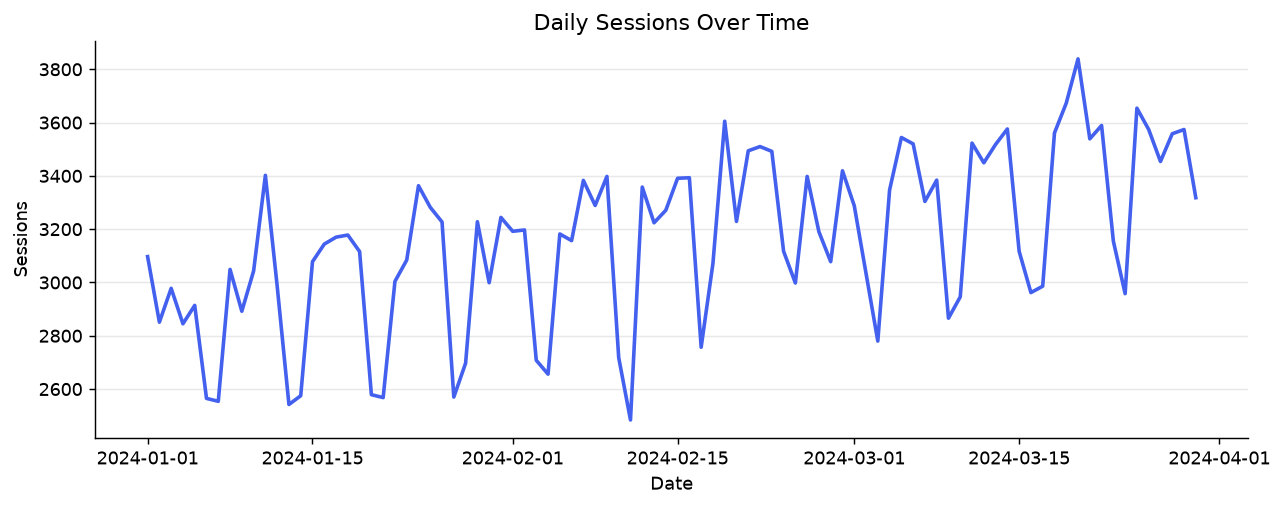

In [3]:
# Your code here
fig, ax = plt.subplots(figsize=(10, 4), dpi=130)

ax.plot(daily['date'], daily['sessions'], color='#4361ee', linewidth=2)
ax.set_xlabel('Date')
ax.set_ylabel('Sessions')
ax.set_title('Daily Sessions Over Time')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('data/practice_01_sessions.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Exercise 2 — Bar chart of total activations by channel

Your manager wants to know which channel drives the most card activations.

Requirements:
- Aggregate total activations per channel
- Sort bars from highest to lowest
- Add value labels on top of each bar
- Use a color of your choice
- Clean spines and grid

💡 Hint: `df.groupby('channel')['activacion_tarjeta'].sum().sort_values(ascending=False)`

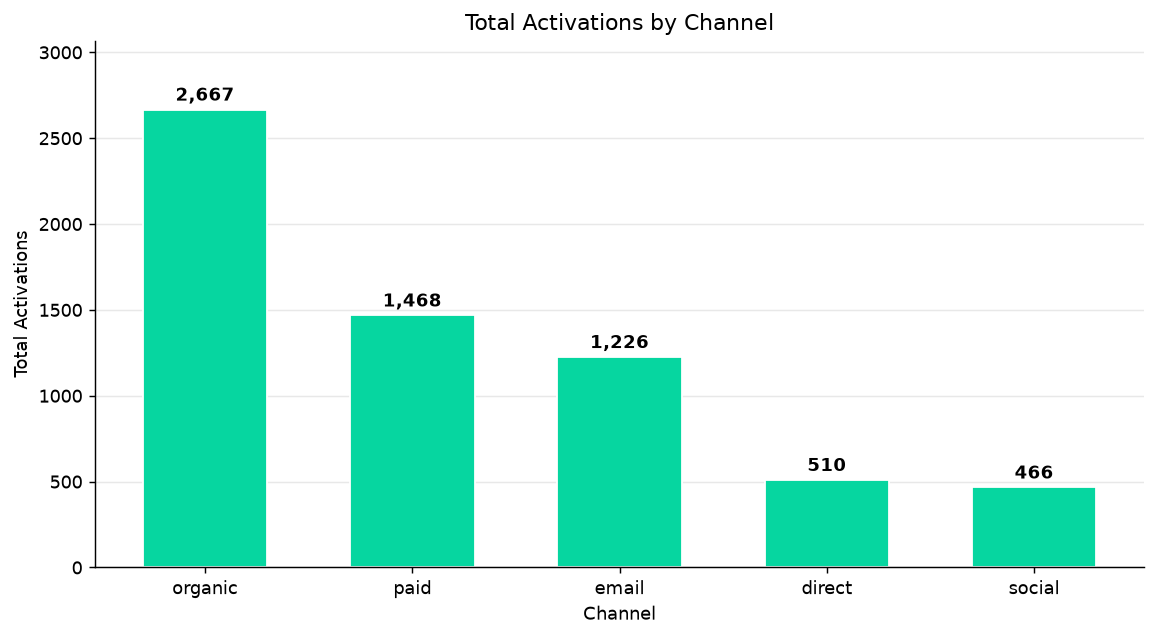

In [4]:
# Your code here
fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

d = df.groupby('channel')['activacion_tarjeta'].sum().sort_values(ascending=False)
bars = ax.bar(d.index, d.values, color='#06d6a0', edgecolor='white', width=0.6)

# Value labels on top of each bar
for bar, val in zip(bars, d.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + d.max() * 0.01,
        f'{int(val):,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Channel')
ax.set_ylabel('Total Activations')
ax.set_title('Total Activations by Channel')
ax.set_ylim(0, d.max() * 1.15)  # headroom for labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---
## Exercise 3 — Multi-line chart: sessions vs OTP completions vs activations

Show the three metrics on the same chart to see how they move together.

Requirements:
- Three lines, each a different color
- Different linestyle for each (solid, dashed, dotted)
- Legend outside the plot (use `loc='upper left'`)
- Apply `rcParams` at the top so you don't repeat styling code

💡 Hint: sessions and activations are very different in scale — consider plotting on two y-axes using `ax.twinx()`

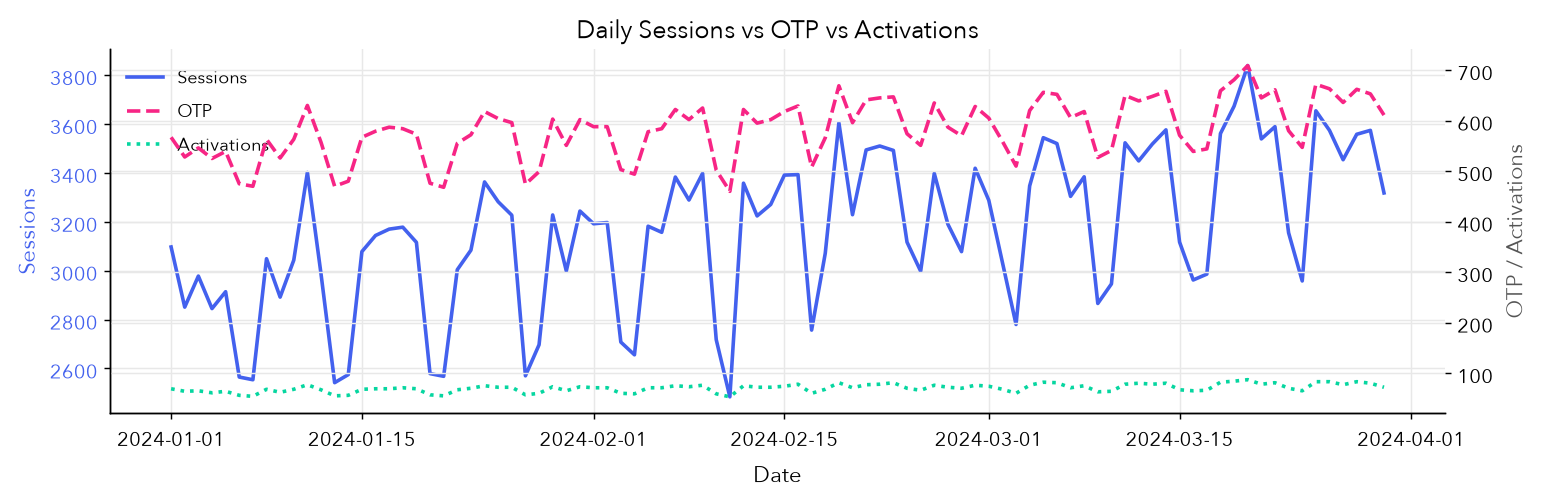

In [ ]:
# Your code here
plt.rcParams.update({
    'font.family':      'Avenir Next', 
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'axes.grid':        True,
    'grid.color':       '#e8e8e8',
    'grid.linewidth':   0.8,
    'axes.axisbelow':   True,
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'legend.frameon':   False,
})

fig, ax1 = plt.subplots(figsize=(12, 4), dpi=130)

# Sessions on left axis (much larger scale)
ax1.plot(daily['date'], daily['sessions'], color='#4361ee', linewidth=2,
         linestyle='-', label='Sessions')
ax1.set_ylabel('Sessions', color='#4361ee')
ax1.tick_params(axis='y', labelcolor='#4361ee')

# OTP and activations share right axis (similar scale)
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['otp'], color='#f72585', linewidth=2,
         linestyle='--', label='OTP')
ax2.plot(daily['date'], daily['activations'], color='#06d6a0', linewidth=2,
         linestyle=':', label='Activations')
ax2.set_ylabel('OTP / Activations', color='#555')
ax2.spines['top'].set_visible(False)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.set_title('Daily Sessions vs OTP vs Activations')
ax1.set_xlabel('Date')

plt.tight_layout()
plt.show()

---
## Bonus — Apply your own rcParams

Define a `rcParams` block at the top of a new cell and re-run exercises 1–3 with it applied.
The goal: all 3 charts should look consistent without repeating styling code in each one.

💡 Hint: `plt.rcParams.update({...})`

In [6]:
# Your rcParams block here
plt.rcParams.update({
    # fill in the keys you want
})